# Offline run analysis

Set `RUN_ID` to an existing run folder. This notebook loads raw training and realtime trial `.npz` files, applies its own preprocessing and audio-cue labeling settings, trains offline model variants, tests each on the realtime trial, and saves sweep outputs back into the same run folder. Here, `filtered_signal` means non-FFT time-domain windows after this notebook's preprocessing step.


In [25]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'training.py').exists():
    ROOT = Path(r'D:/BME/BCI/online_bci/online_eeg')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from preprocessing import (
    AudioLabelConfig,
    PreprocessConfig,
    labeled_preprocess_summary,
    preprocess_recording,
)
from training import TrainingConfig, offline_train_test_sweep
from plots import plot_labeled_recording, plot_predictions_overlay

print('Pipeline root:', ROOT)


Pipeline root: e:\UCI\BCI\online\online_bci\online_eeg


## Raw files, preprocessing, and sweep settings


In [26]:
RUN_ID = 'run_001'
RUN_DIR = ROOT / 'runs' / RUN_ID

TRAIN_RAW_NPZ = RUN_DIR / 'raw_training' / 'train_01.npz'
TEST_RAW_NPZ = RUN_DIR / 'realtime_trials' / 'realtime_trial_01_raw.npz'

EEG_CHANNELS = (1, 2, 3, 4)
EEG_CHANNEL_NAMES = ('O1', 'Oz', 'O2', 'POz')
AUDIO_CHANNEL = 16

APPLY_SOFTWARE_FILTERS = True  # BIOPAC hardware already bandpasses the EEG at 1-35 Hz.
DEMEAN_CHANNELS = True
SOFTWARE_BANDPASS_HZ = None  # Set to (1.0, 35.0) only if APPLY_SOFTWARE_FILTERS=True.
SOFTWARE_NOTCH_HZ = None  # Set to (60.0,) only if APPLY_SOFTWARE_FILTERS=True.
PREPROCESS_TAG = 'software_filters_on' if APPLY_SOFTWARE_FILTERS else 'hardware_filter_only'
if DEMEAN_CHANNELS:
    PREPROCESS_TAG += '_demeaned'

OFFLINE_LABELED_DIR = RUN_DIR / 'offline_labeled' / PREPROCESS_TAG
TRAIN_LABELED_NPZ = OFFLINE_LABELED_DIR / f'{TRAIN_RAW_NPZ.stem}_labeled.npz'
TEST_LABELED_NPZ = OFFLINE_LABELED_DIR / f'{TEST_RAW_NPZ.stem}_labeled.npz'
SWEEP_DIR = RUN_DIR / 'offline_sweeps' / PREPROCESS_TAG

# FEATURE_MODES = ('filtered_signal', 'fft_bandpower')
FEATURE_MODES = ('filtered_signal',)

# WINDOW_SECS = (1.0, 2.0, 3.0)
WINDOW_SECS = (1.0,)
# STRIDE_SECS = (0.05, 0.1, 0.2)
STRIDE_SECS = (0.1,)
# FFT_BANDPOWER_HZ_VALUES = ((8.0, 12.0), (1, 35), (8, 30))
FFT_BANDPOWER_HZ_VALUES = ((8.0, 12.0),)
LABEL_MODE = 'endpoint'  # use 'majority' or 'endpoint'.

PRE = PreprocessConfig(
    eeg_channels=EEG_CHANNELS,
    audio_channel=AUDIO_CHANNEL,
    apply_software_filters=APPLY_SOFTWARE_FILTERS,
    bandpass_low_hz=8 if SOFTWARE_BANDPASS_HZ is None else SOFTWARE_BANDPASS_HZ[0],
    bandpass_high_hz=35 if SOFTWARE_BANDPASS_HZ is None else SOFTWARE_BANDPASS_HZ[1],
    notch_hz=SOFTWARE_NOTCH_HZ,
    notch_quality_factor=30.0,
    filter_order=4,
    demean_channels=DEMEAN_CHANNELS,
)

LABELS = AudioLabelConfig(
    class_names=('Eyes Open', 'Eyes Closed'),
    baseline_label=0,
    active_label=1,
    cue_label_sequence=None,
    alternate_binary_labels=True,
    label_duration_sec=None,  # transition mode: each cue switches state until the next cue.
    label_start_offset_sec=0.0,  # label switch starts exactly at cue onset.
    envelope_window_sec=0.025,
    onset_threshold=None,
    onset_min_interval_sec=0.50,
)

TRAIN = TrainingConfig(
    train_fraction=0.9,
    hidden_size=64,
    num_layers=2,
    dropout=0.25,
    batch_size=64,
    epochs=20,
    lr=1e-3,
    seed=888,
)

if not RUN_DIR.exists():
    raise FileNotFoundError(f'Run folder not found: {RUN_DIR}')
if not TRAIN_RAW_NPZ.exists():
    raise FileNotFoundError(f'Training raw file not found: {TRAIN_RAW_NPZ}')
if not TEST_RAW_NPZ.exists():
    raise FileNotFoundError(f'Test raw file not found: {TEST_RAW_NPZ}')

OFFLINE_LABELED_DIR.mkdir(parents=True, exist_ok=True)
SWEEP_DIR.mkdir(parents=True, exist_ok=True)
print('Run directory:', RUN_DIR)
print('Training raw file:', TRAIN_RAW_NPZ)
print('Test raw file:', TEST_RAW_NPZ)
print('Offline labeled output:', OFFLINE_LABELED_DIR)
print('Sweep output:', SWEEP_DIR)
print('Software filters enabled:', APPLY_SOFTWARE_FILTERS)


Run directory: e:\UCI\BCI\online\online_bci\online_eeg\runs\run_001
Training raw file: e:\UCI\BCI\online\online_bci\online_eeg\runs\run_001\raw_training\train_01.npz
Test raw file: e:\UCI\BCI\online\online_bci\online_eeg\runs\run_001\realtime_trials\realtime_trial_01_raw.npz
Offline labeled output: e:\UCI\BCI\online\online_bci\online_eeg\runs\run_001\offline_labeled\software_filters_on_demeaned
Sweep output: e:\UCI\BCI\online\online_bci\online_eeg\runs\run_001\offline_sweeps\software_filters_on_demeaned
Software filters enabled: True


## Preprocess raw files for this offline analysis


In [27]:
TRAIN_LABELED_NPZ, train_cue_table = preprocess_recording(
    raw_npz=TRAIN_RAW_NPZ,
    output_npz=TRAIN_LABELED_NPZ,
    preprocess_config=PRE,
    label_config=LABELS,
)
TEST_LABELED_NPZ, test_cue_table = preprocess_recording(
    raw_npz=TEST_RAW_NPZ,
    output_npz=TEST_LABELED_NPZ,
    preprocess_config=PRE,
    label_config=LABELS,
)

preprocess_summary = labeled_preprocess_summary({
    'training': TRAIN_LABELED_NPZ,
    'realtime_test': TEST_LABELED_NPZ,
})
display(preprocess_summary)

print('Training cue table')
display(train_cue_table)
print('Realtime test cue table')
display(test_cue_table)


,name,path,samplerate,duration_sec,has_preprocess_config,has_apply_software_filters_flag,apply_software_filters,demean_channels,bandpass_low_hz,bandpass_high_hz,notch_hz,eeg_channels,audio_channel,source_raw_npz
0,training,e:\UCI\BCI\online\online_bci\online_eeg\runs\r...,200,300.0,True,True,True,True,8,35,None,"[1, 2, 3, 4]",16,e:\UCI\BCI\online\online_bci\online_eeg\runs\r...
1,realtime_test,e:\UCI\BCI\online\online_bci\online_eeg\runs\r...,200,30.0,True,True,True,True,8,35,None,"[1, 2, 3, 4]",16,e:\UCI\BCI\online\online_bci\online_eeg\runs\r...


Training cue table


,cue_index,onset_sample,onset_time_sec,label_start_sample,label_end_sample,label_start_time_sec,label_end_time_sec,label,label_name,peak_value
0,0,1155,5.775,1155,2163,5.775,10.815,1,Eyes Closed,1.030212
1,1,2163,10.815,2163,3135,10.815,15.675,0,Eyes Open,1.040991
2,2,3135,15.675,3135,4183,15.675,20.915,1,Eyes Closed,1.046932
3,3,4183,20.915,4183,5851,20.915,29.255,0,Eyes Open,1.041953
4,4,5851,29.255,5851,7508,29.255,37.540,1,Eyes Closed,1.047938
5,5,7508,37.540,7508,8295,37.540,41.475,0,Eyes Open,1.047303
6,6,8295,41.475,8295,9107,41.475,45.535,1,Eyes Closed,1.044649
7,7,9107,45.535,9107,11099,45.535,55.495,0,Eyes Open,1.044290
8,8,11099,55.495,11099,13139,55.495,65.695,1,Eyes Closed,1.039200
9,9,13139,65.695,13139,13711,65.695,68.555,0,Eyes Open,1.049705


Realtime test cue table


,cue_index,onset_sample,onset_time_sec,label_start_sample,label_end_sample,label_start_time_sec,label_end_time_sec,label,label_name,peak_value
0,0,1715,8.575,1715,3331,8.575,16.655,1,Eyes Closed,1.038022
1,1,3331,16.655,3331,5030,16.655,25.150,0,Eyes Open,1.035590
2,2,5030,25.150,5030,6000,25.150,30.000,1,Eyes Closed,1.040509


## Inspect freshly labeled train/test data


Text(0.5, 1.0, 'Training labeled EEG preview')

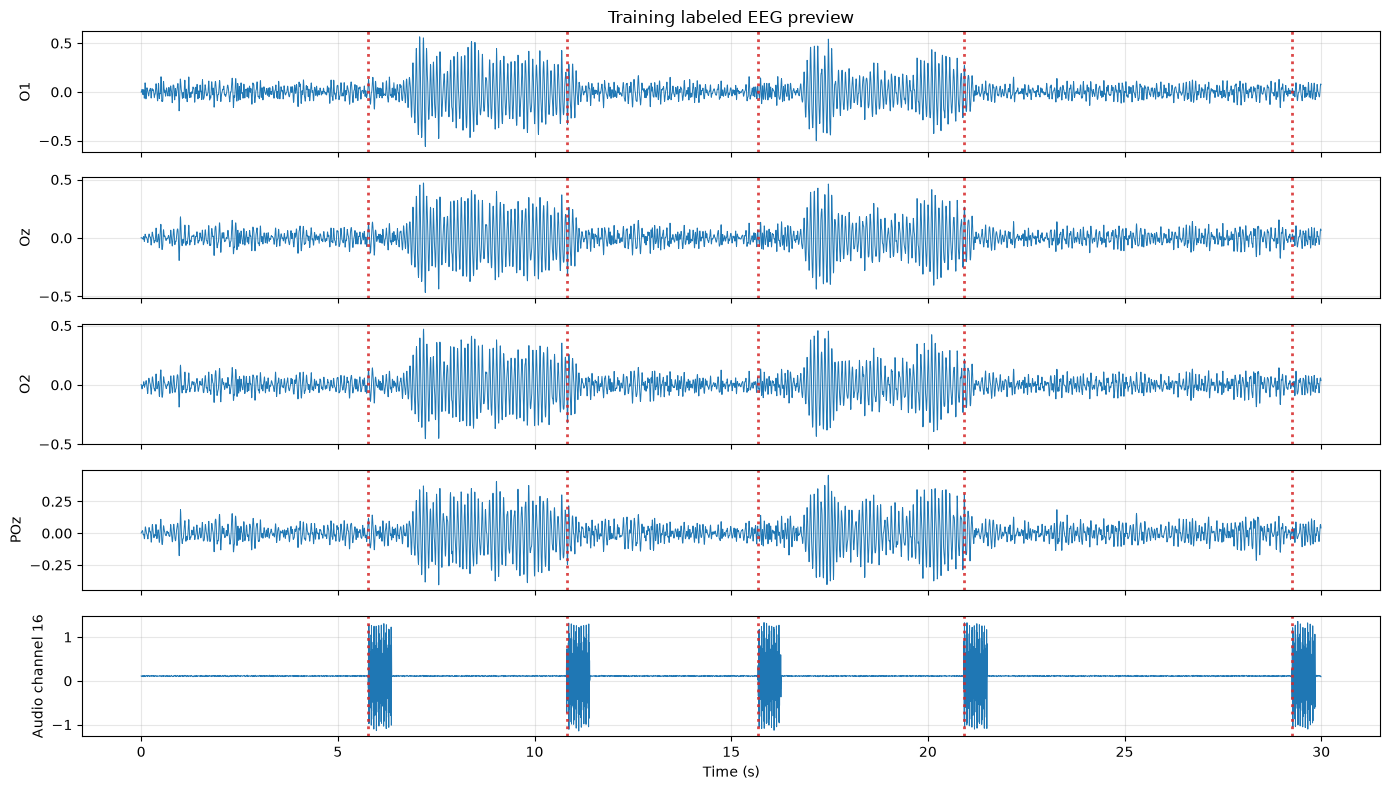

In [28]:
fig, axes = plot_labeled_recording(
    TRAIN_LABELED_NPZ,
    max_duration_sec=30.0,
    channel_names=EEG_CHANNEL_NAMES,
)
axes[0].set_title('Training labeled EEG preview')


Text(0.5, 1.0, 'Realtime trial labeled EEG preview')

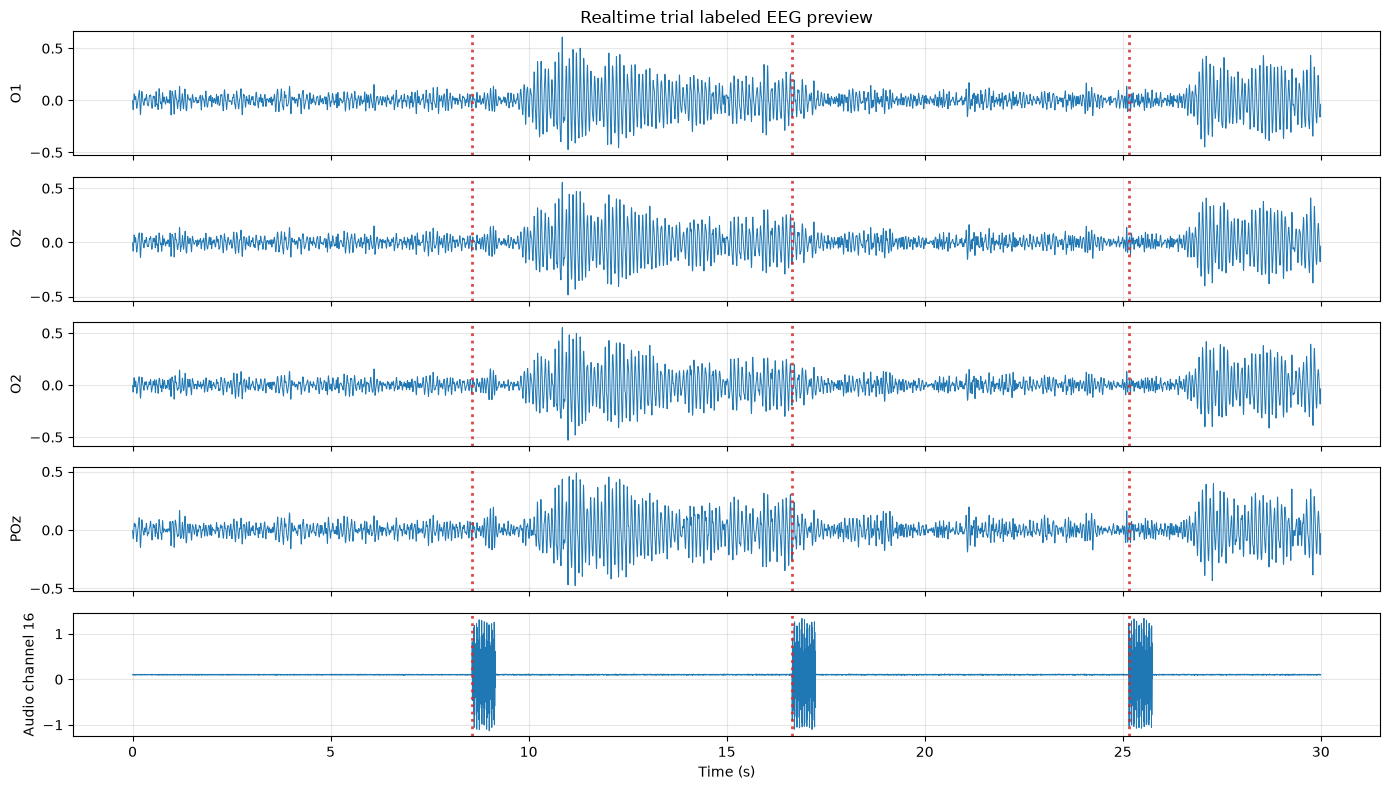

In [29]:
fig, axes = plot_labeled_recording(
    TEST_LABELED_NPZ,
    max_duration_sec=None,
    channel_names=EEG_CHANNEL_NAMES,
)
axes[0].set_title('Realtime trial labeled EEG preview')


## Run offline model sweep

In [30]:
sweep_result = offline_train_test_sweep(
    train_labeled_npz=TRAIN_LABELED_NPZ,
    test_labeled_npz=TEST_LABELED_NPZ,
    output_dir=SWEEP_DIR,
    feature_modes=FEATURE_MODES,
    window_secs=WINDOW_SECS,
    stride_secs=STRIDE_SECS,
    bandpower_hz_values=FFT_BANDPOWER_HZ_VALUES,
    training_config=TRAIN,
    label_mode=LABEL_MODE,
)

summary = sweep_result['summary'].sort_values('test_balanced_accuracy', ascending=False).reset_index(drop=True)
print('Saved sweep summary:', sweep_result['summary_csv'])
display(summary)


Saved sweep summary: e:\UCI\BCI\online\online_bci\online_eeg\runs\run_001\offline_sweeps\software_filters_on_demeaned\offline_sweep_summary.csv


,variant,feature_mode,window_sec,stride_sec,bandpower_low_hz,bandpower_high_hz,checkpoint_path,variant_dir,val_accuracy,val_balanced_accuracy,...,test_n_windows,test_mean_cue_to_first_correct_sec,test_median_cue_to_first_correct_sec,test_mean_cue_to_predicted_transition_sec,test_median_cue_to_predicted_transition_sec,test_mean_cue_to_sustained_prediction_sec,test_median_cue_to_sustained_prediction_sec,test_xcov_delay_sec,test_xcov_peak_coeff,test_xcov_signal_column
0,filtered_signal__win_1p0s__stride_0p1s__labels...,filtered_signal,1.0,0.1,NaN,NaN,e:\UCI\BCI\online\online_bci\online_eeg\runs\r...,e:\UCI\BCI\online\online_bci\online_eeg\runs\r...,0.892977,0.889407,...,291.0,1.04,0.845,1.04,0.845,1.406667,1.625,1.625,0.920632,prob_Eyes Closed


## Compare variants

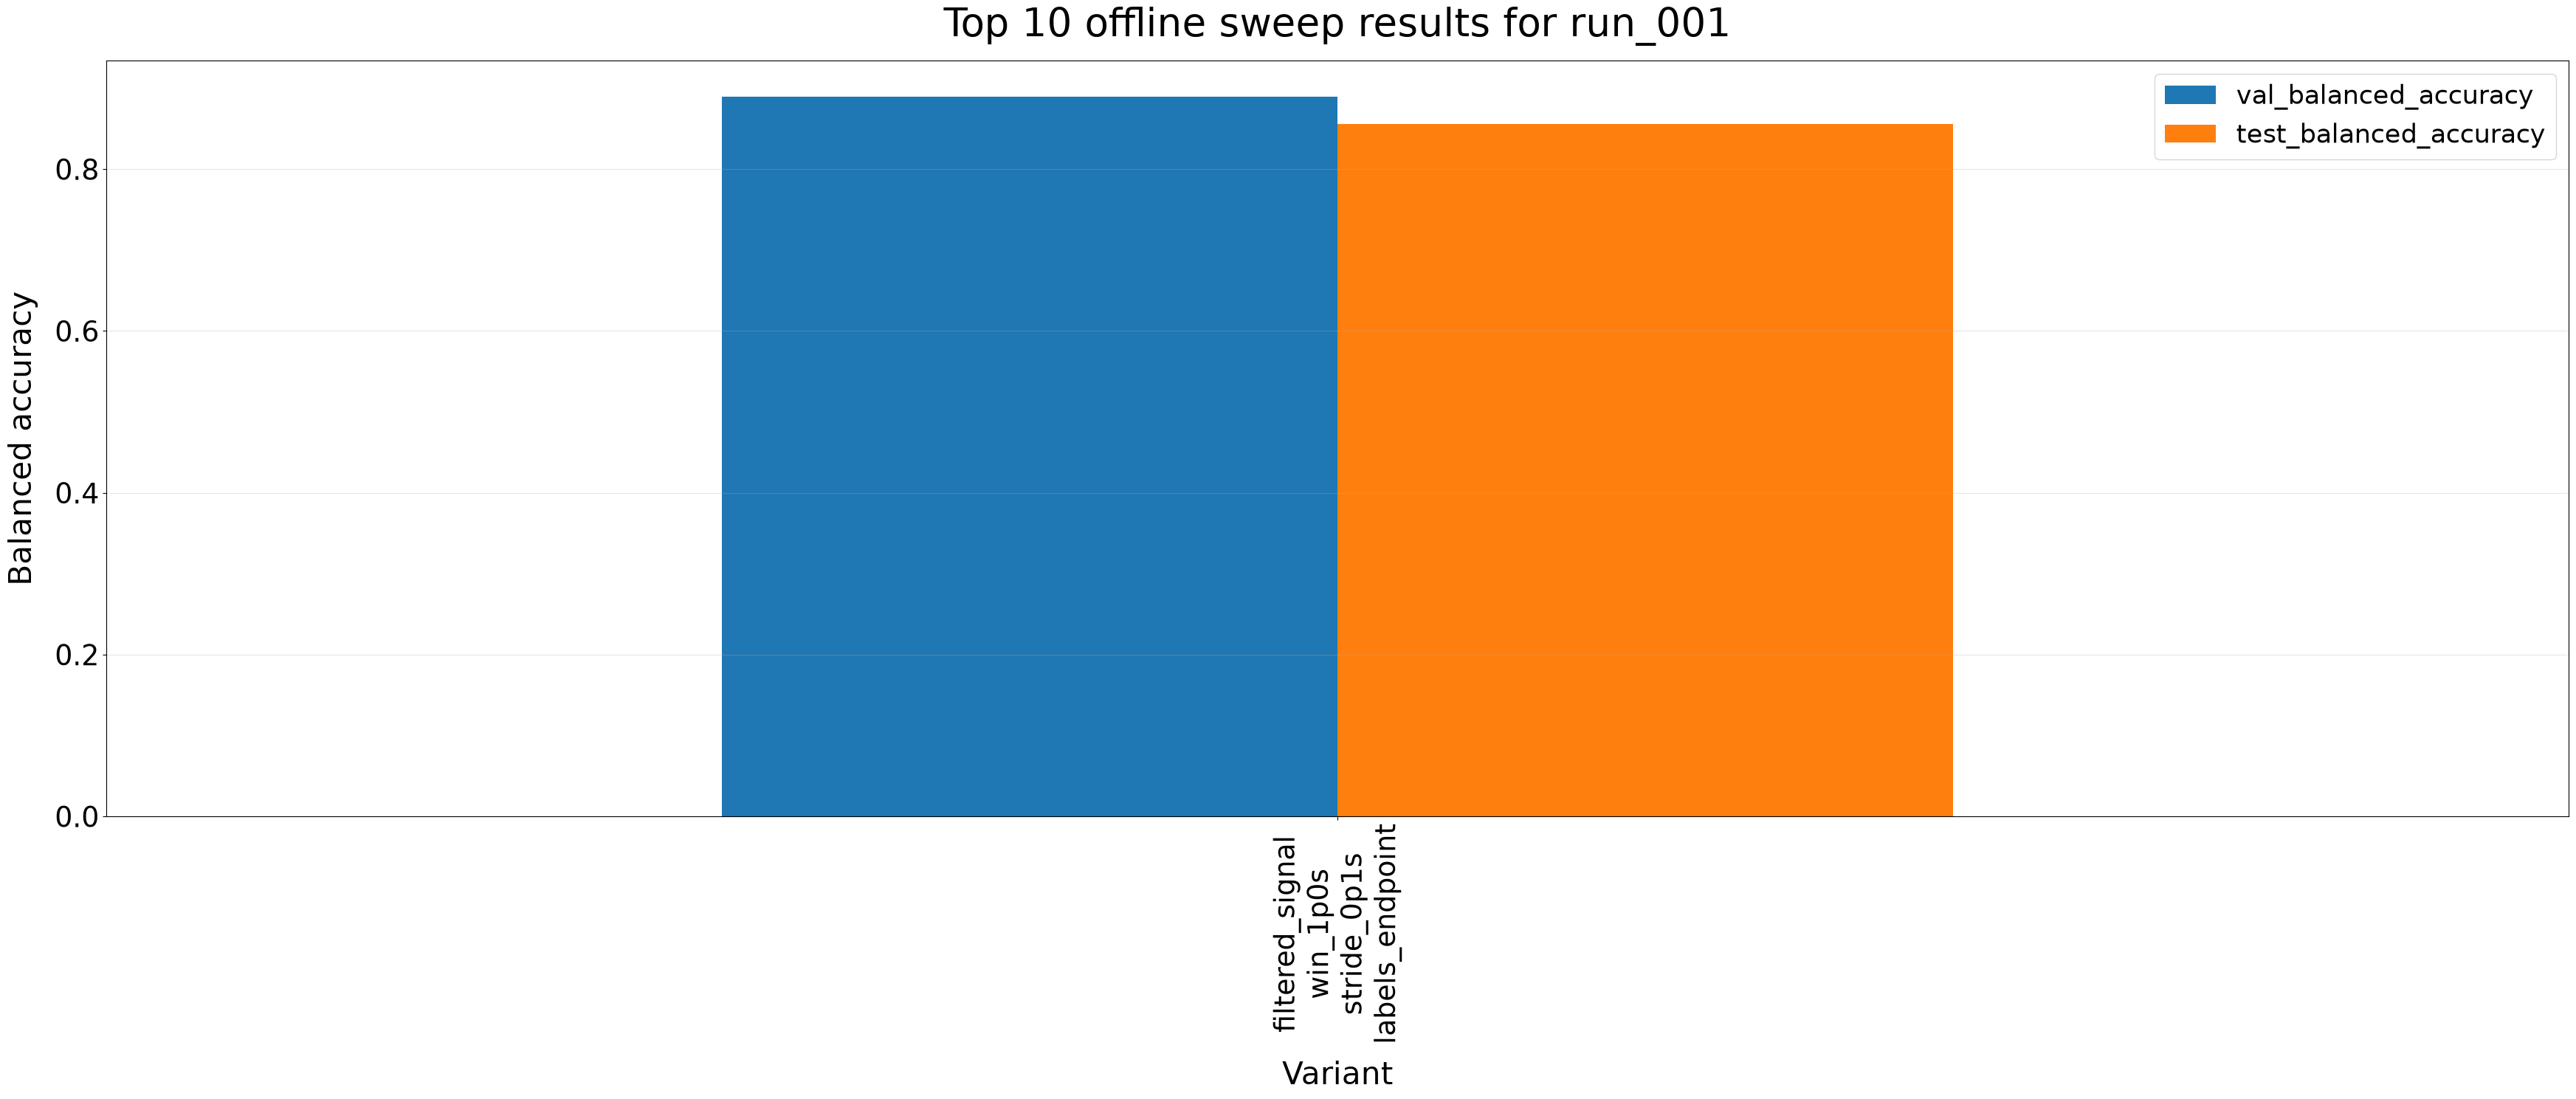

In [31]:
TOP_N_VARIANTS = 10
plot_df = summary.head(TOP_N_VARIANTS).copy()
plot_df['variant_short'] = plot_df['variant'].str.replace('__', '\n', regex=False)
ax = plot_df.plot.bar(
    x='variant_short',
    y=['val_balanced_accuracy', 'test_balanced_accuracy'],
    figsize=(35, 15),
)
ax.set_xlabel('Variant', fontsize=30, labelpad=16)
ax.set_ylabel('Balanced accuracy', fontsize=30, labelpad=16)
ax.set_title(f'Top {TOP_N_VARIANTS} offline sweep results for {RUN_ID}', fontsize=38, pad=24)
ax.tick_params(axis='x', labelsize=27, rotation=90)
ax.tick_params(axis='y', labelsize=27)
ax.legend(fontsize=25)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()


## Inspect best variant predictions

Best variant: filtered_signal__win_1p0s__stride_0p1s__labels_endpoint
Best predictions: e:\UCI\BCI\online\online_bci\online_eeg\runs\run_001\offline_sweeps\software_filters_on_demeaned\filtered_signal__win_1p0s__stride_0p1s__labels_endpoint\realtime_trial_01_raw_labeled_test_predictions.csv


,recording_id,start_sample,end_sample,start_time_sec,end_time_sec,label,true_label,pred_label,correct,prob_Eyes Open,prob_Eyes Closed
286,realtime_trial_01,5720,5920,28.6,29.6,1,1,1,True,0.017207,0.982793
287,realtime_trial_01,5740,5940,28.7,29.7,1,1,1,True,0.018043,0.981957
288,realtime_trial_01,5760,5960,28.8,29.8,1,1,1,True,0.013737,0.986263
289,realtime_trial_01,5780,5980,28.9,29.9,1,1,1,True,0.017952,0.982048
290,realtime_trial_01,5800,6000,29.0,30.0,1,1,1,True,0.030424,0.969576


,n_cues,n_matched_first_correct,mean_cue_to_first_correct_sec,median_cue_to_first_correct_sec,n_matched_predicted_transition,mean_cue_to_predicted_transition_sec,median_cue_to_predicted_transition_sec,n_matched_sustained,mean_cue_to_sustained_prediction_sec,median_cue_to_sustained_prediction_sec
0,3,3,1.04,0.845,3,1.04,0.845,3,1.406667,1.625


,target_label,target_label_name,prediction_signal_column,xcov_delay_sec,xcov_lag_samples,xcov_peak_coeff,max_lag_sec,n_valid_samples
0,1,Eyes Closed,prob_Eyes Closed,1.625,325,0.920632,10.0,5800


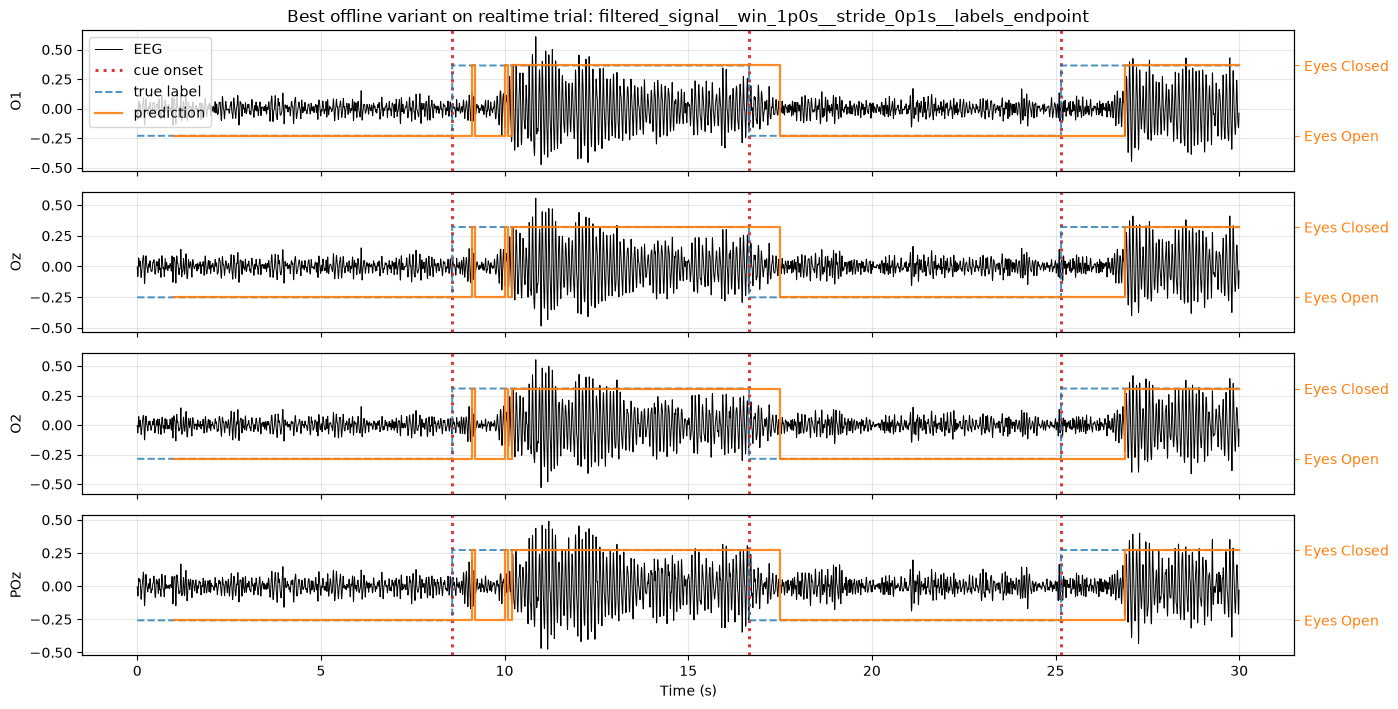

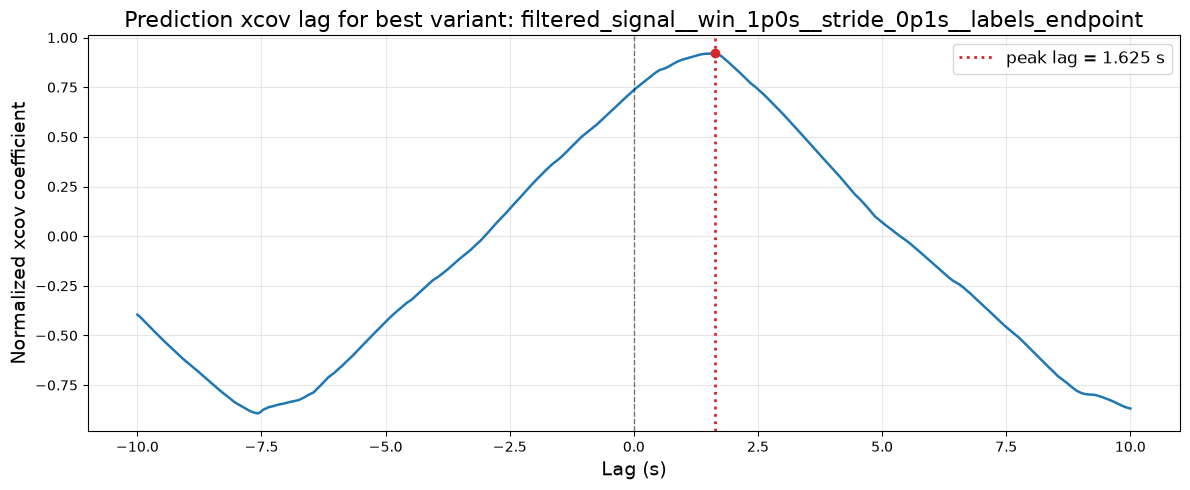

In [32]:
best = summary.iloc[0]
best_variant_dir = Path(best['variant_dir'])
best_pred_csv = best_variant_dir / f'{TEST_LABELED_NPZ.stem}_test_predictions.csv'
best_cue_delay_summary_csv = best_variant_dir / f'{TEST_LABELED_NPZ.stem}_test_cue_delay_summary.csv'
best_xcov_delay_summary_csv = best_variant_dir / f'{TEST_LABELED_NPZ.stem}_test_xcov_delay_summary.csv'
best_xcov_curve_csv = best_variant_dir / f'{TEST_LABELED_NPZ.stem}_test_xcov_curve.csv'

print('Best variant:', best['variant'])
print('Best predictions:', best_pred_csv)

best_predictions = pd.read_csv(best_pred_csv)
display(best_predictions.tail())

best_cue_delay_summary = pd.read_csv(best_cue_delay_summary_csv) if best_cue_delay_summary_csv.exists() else None
best_xcov_delay_summary = pd.read_csv(best_xcov_delay_summary_csv) if best_xcov_delay_summary_csv.exists() else None
best_xcov_curve = pd.read_csv(best_xcov_curve_csv) if best_xcov_curve_csv.exists() else None

if best_cue_delay_summary is not None:
    display(best_cue_delay_summary)
if best_xcov_delay_summary is not None:
    display(best_xcov_delay_summary)

fig, axes = plot_predictions_overlay(
    TEST_LABELED_NPZ,
    best_predictions,
    max_duration_sec=None,
    channel_names=EEG_CHANNEL_NAMES,
    show_true_labels=True,
)
axes[0].set_title(f"Best offline variant on realtime trial: {best['variant']}")

if best_xcov_curve is not None and best_xcov_delay_summary is not None:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(best_xcov_curve['lag_sec'], best_xcov_curve['xcov_coeff'], linewidth=1.8)
    peak_delay = float(best_xcov_delay_summary.loc[0, 'xcov_delay_sec'])
    peak_coeff = float(best_xcov_delay_summary.loc[0, 'xcov_peak_coeff'])
    ax.axvline(peak_delay, linestyle=':', color='tab:red', linewidth=2.0, label=f'peak lag = {peak_delay:.3f} s')
    ax.scatter([peak_delay], [peak_coeff], color='tab:red', zorder=3)
    ax.axvline(0.0, linestyle='--', color='black', alpha=0.5, linewidth=1.0)
    ax.set_xlabel('Lag (s)', fontsize=14)
    ax.set_ylabel('Normalized xcov coefficient', fontsize=14)
    ax.set_title(f"Prediction xcov lag for best variant: {best['variant']}", fontsize=16)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12)
    plt.tight_layout()
